In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# T1
t1_train = pd.read_csv("../multi_omics/T1_train_selected.csv")
t1_test = pd.read_csv("../multi_omics/T1_test_selected.csv")

# T2
t2_train = pd.read_csv("../multi_omics/T2_train_selected.csv")
t2_test = pd.read_csv("../multi_omics/T2_test_selected.csv")

# ADC
adc_train = pd.read_csv("../multi_omics/ADC_train_selected.csv")
adc_test = pd.read_csv("../multi_omics/ADC_test_selected.csv")

def split_X_y(df):
    X = df.drop(columns=["label"])
    y = df["label"]
    return X, y

X_t1_train, y_t1_train = split_X_y(t1_train)
X_t1_test, y_t1_test = split_X_y(t1_test)

X_t2_train, y_t2_train = split_X_y(t2_train)
X_t2_test, y_t2_test = split_X_y(t2_test)

X_adc_train, y_adc_train = split_X_y(adc_train)
X_adc_test, y_adc_test = split_X_y(adc_test)

In [9]:
# check loading
print((y_t1_train == y_t2_train).all(), (y_t1_train == y_adc_train).all())
print((y_t1_test == y_t2_test).all(), (y_t1_test == y_adc_test).all())

True True
True True


In [10]:
train_dict = {
    "T1":  (X_t1_train, y_t1_train),
    "T2":  (X_t2_train, y_t2_train),
    "ADC": (X_adc_train, y_adc_train)
}

test_dict = {
    "T1":  (X_t1_test, y_t1_test),
    "T2":  (X_t2_test, y_t2_test),
    "ADC": (X_adc_test, y_adc_test)
}

# Single and Early Fusion Baselines (LR and SVM) 

In [11]:
feature_sets_train = {
    "T1": (X_t1_train, y_t1_train),
    "T2": (X_t2_train, y_t2_train),
    "ADC": (X_adc_train, y_adc_train),
    "T1+T2": (pd.concat([X_t1_train, X_t2_train], axis=1), y_t1_train),
    "T1+ADC": (pd.concat([X_t1_train, X_adc_train], axis=1), y_t1_train),
    "T2+ADC": (pd.concat([X_t2_train, X_adc_train], axis=1), y_t2_train),
    "T1+T2+ADC": (pd.concat([X_t1_train, X_t2_train, X_adc_train], axis=1), y_t1_train),
}

feature_sets_test = {
    "T1": (X_t1_test, y_t1_test),
    "T2": (X_t2_test, y_t2_test),
    "ADC": (X_adc_test, y_adc_test),
    "T1+T2": (pd.concat([X_t1_test, X_t2_test], axis=1), y_t1_test),
    "T1+ADC": (pd.concat([X_t1_test, X_adc_test], axis=1), y_t1_test),
    "T2+ADC": (pd.concat([X_t2_test, X_adc_test], axis=1), y_t2_test),
    "T1+T2+ADC": (pd.concat([X_t1_test, X_t2_test, X_adc_test], axis=1), y_t1_test),
}

## Simple Logistic Regression and SVM (without kernel)

In [12]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve, auc
)


def classification_error(y_true, y_pred):
    return 1.0 - accuracy_score(y_true, y_pred)


def make_model(method, C, penalty="l2"):
    if method == "logistic":
        return LogisticRegression(
            penalty=penalty,
            C=C,
            solver="liblinear",
            max_iter=1000
        )
    elif method == "linear_svm":
        return LinearSVC(
            C=C,
            max_iter=20000
        )
    else:
        raise ValueError("method must be 'logistic' or 'linear_svm'")


def get_model_score(model, X, method):
    """
    Return a continuous score for AUC:
    - logistic: probability of class 1
    - linear_svm: decision function
    """
    if method == "logistic":
        return model.predict_proba(X)[:, 1]
    elif method == "linear_svm":
        return model.decision_function(X)
    else:
        raise ValueError("method must be 'logistic' or 'linear_svm'")


def cv_tune_model(X, y, C_grid, method, penalty="l2", n_splits=5, random_state=42):
    X = np.asarray(X)
    y = np.asarray(y)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    best_score = -np.inf   # maximize AUC
    best_C = None

    for C in C_grid:
        fold_aucs = []

        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            model = make_model(method, C, penalty=penalty)
            model.fit(X_tr, y_tr)

            val_score = get_model_score(model, X_val, method)
            auc = roc_auc_score(y_val, val_score)
            fold_aucs.append(auc)

        mean_auc = np.mean(fold_aucs)

        if mean_auc > best_score:
            best_score = mean_auc
            best_C = C

    return best_C, best_score


def evaluate_model(X_train, y_train, X_test, y_test, C, method, penalty="l2"):
    X_train = np.asarray(X_train)
    X_test = np.asarray(X_test)

    model = make_model(method, C, penalty=penalty)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_score = get_model_score(model, X_train, method)
    test_score = get_model_score(model, X_test, method)

    train_err = classification_error(y_train, y_train_pred)
    test_err = classification_error(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, train_score)
    test_auc = roc_auc_score(y_test, test_score)

    train_cm = confusion_matrix(y_train, y_train_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)

    train_report = classification_report(y_train, y_train_pred)
    test_report = classification_report(y_test, y_test_pred)

    return (
        model,
        train_err,
        test_err,
        train_auc,
        test_auc,
        train_cm,
        test_cm,
        train_report,
        test_report
    )

In [13]:
C_grid = [0.01, 0.1, 1, 10, 100]

linear_results = []
late_fusion_prepared = {"T1": [None, None], "T2": [None, None], "ADC": [None, None]}
best_model = None

method_name_map = {
    "logistic": "Linear Logistic Regression",
    "linear_svm": "Linear SVM"
}

late_fusion_idx_map = {
    "logistic": 0,
    "linear_svm": 1
}

for name in feature_sets_train:
    print(f"\n===== {name} =====")

    Xtr = feature_sets_train[name][0].to_numpy()
    Xte = feature_sets_test[name][0].to_numpy()
    ytr = feature_sets_train[name][1].to_numpy()
    yte = feature_sets_test[name][1].to_numpy()

    for method in ["logistic", "linear_svm"]:
        best_C, cv_auc = cv_tune_model(
            Xtr, ytr, C_grid,
            method=method,
            penalty="l2"
        )

        (
            model,
            train_err,
            test_err,
            train_auc,
            test_auc,
            train_cm,
            test_cm,
            train_report,
            test_report
        ) = evaluate_model(
            Xtr, ytr, Xte, yte,
            C=best_C,
            method=method,
            penalty="l2"
        )

        linear_results.append({
            "Feature_Set": name,
            "Model": method_name_map[method],
            "Best_C": best_C,
            "CV_AUC": cv_auc,
            "Train_AUC": train_auc,
            "Test_AUC": test_auc,
            "Train_Error": train_err,
            "Test_Error": test_err
        })

        print(f"{method_name_map[method]}: best C = {best_C}")
        print(f"  CV AUC      = {cv_auc:.6f}")
        print(f"  train AUC   = {train_auc:.6f}")
        print(f"  test AUC    = {test_auc:.6f}")
        print(f"  train error = {train_err:.6f}")
        print(f"  test error  = {test_err:.6f}")

        # store single-modality fitted models for late fusion
        if name in ["T1", "T2", "ADC"]:
            late_fusion_prepared[name][late_fusion_idx_map[method]] = model
        if name == "T1+T2" and method == "logistic":
            best_model = model

# convert stored lists back to tuples
late_fusion_prepared = {k: tuple(v) for k, v in late_fusion_prepared.items()}

linear_results_df = pd.DataFrame(linear_results)

linear_summary = linear_results_df[
    ["Feature_Set", "Model", "Best_C", "CV_AUC", "Train_AUC", "Test_AUC", "Train_Error", "Test_Error"]
]

linear_summary


===== T1 =====
Linear Logistic Regression: best C = 1
  CV AUC      = 0.885538
  train AUC   = 0.901380
  test AUC    = 0.867974
  train error = 0.110266
  test error  = 0.121212
Linear SVM: best C = 0.1
  CV AUC      = 0.874435
  train AUC   = 0.900899
  test AUC    = 0.883660
  train error = 0.106464
  test error  = 0.121212

===== T2 =====
Linear Logistic Regression: best C = 0.01
  CV AUC      = 0.861433
  train AUC   = 0.867758
  test AUC    = 0.828758
  train error = 0.117871
  test error  = 0.181818
Linear SVM: best C = 0.01
  CV AUC      = 0.856366
  train AUC   = 0.873295
  test AUC    = 0.837908
  train error = 0.114068
  test error  = 0.181818

===== ADC =====
Linear Logistic Regression: best C = 0.01
  CV AUC      = 0.860694
  train AUC   = 0.878751
  test AUC    = 0.809150
  train error = 0.136882
  test error  = 0.196970
Linear SVM: best C = 0.01
  CV AUC      = 0.846847
  train AUC   = 0.885171
  test AUC    = 0.786928
  train error = 0.125475
  test error  = 0.166667



,Feature_Set,Model,Best_C,CV_AUC,Train_AUC,Test_AUC,Train_Error,Test_Error
0,T1,Linear Logistic Regression,1.00,0.885538,0.901380,0.867974,0.110266,0.121212
1,T1,Linear SVM,0.10,0.874435,0.900899,0.883660,0.106464,0.121212
2,T2,Linear Logistic Regression,0.01,0.861433,0.867758,0.828758,0.117871,0.181818
3,T2,Linear SVM,0.01,0.856366,0.873295,0.837908,0.114068,0.181818
4,ADC,Linear Logistic Regression,0.01,0.860694,0.878751,0.809150,0.136882,0.196970
5,ADC,Linear SVM,0.01,0.846847,0.885171,0.786928,0.125475,0.166667
6,T1+T2,Linear Logistic Regression,0.10,0.902603,0.913818,0.929412,0.098859,0.121212
7,T1+T2,Linear SVM,0.01,0.892185,0.912695,0.930719,0.095057,0.121212
8,T1+ADC,Linear Logistic Regression,0.01,0.890815,0.893516,0.966013,0.121673,0.106061
9,T1+ADC,Linear SVM,0.01,0.873336,0.906917,0.960784,0.098859,0.121212


## Best Baseline Model: T1+T2

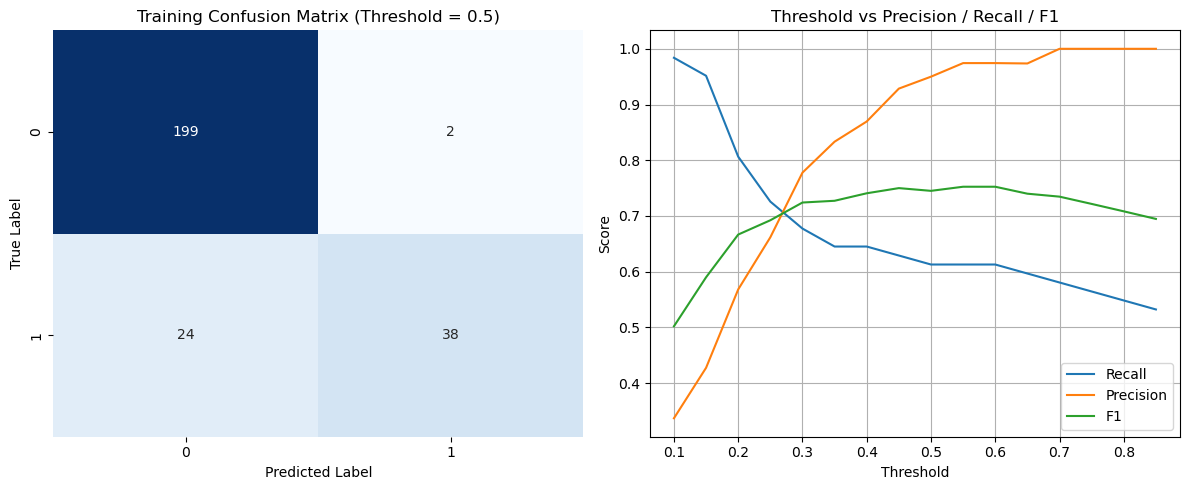

In [20]:
from sklearn.metrics import confusion_matrix

Xtr = feature_sets_train["T1+T2"][0].to_numpy()
ytr = feature_sets_train["T1+T2"][1].to_numpy()
Xte = feature_sets_test["T1+T2"][0].to_numpy()
yte = feature_sets_test["T1+T2"][1].to_numpy()

model = best_model
y_train_pred = model.predict(Xtr)
train_cm = confusion_matrix(ytr, y_train_pred)

y_prob_train = model.predict_proba(Xtr)[:, 1]
y_prob_test = model.predict_proba(Xte)[:, 1]

threshold_grid = np.arange(0.1, 0.9, 0.05)
results = []

for t in threshold_grid:
    y_pred = (y_prob_train >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(ytr, y_pred).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        "threshold": t,
        "recall": recall,
        "precision": precision,
        "f1": f1
    })

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- (1) Confusion Matrix ---
sns.heatmap(
    train_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[0, 1],
    yticklabels=[0, 1],
    ax=axes[0]
)
axes[0].set_title("Training Confusion Matrix (Threshold = 0.5)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# --- (2) Threshold Curve ---
axes[1].plot(results_df["threshold"], results_df["recall"], label="Recall")
axes[1].plot(results_df["threshold"], results_df["precision"], label="Precision")
axes[1].plot(results_df["threshold"], results_df["f1"], label="F1")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Threshold vs Precision / Recall / F1")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [22]:
# inspect best thresholds by F1 
print(results_df.sort_values("f1", ascending=False).head(10))
 
# test ROC and accuracy at best F1 threshold 
threshold = 0.55 
y_test_pred = (y_prob_test >= threshold).astype(int) 
test_cm = confusion_matrix(yte, y_test_pred) 
test_report = classification_report(yte, y_test_pred) 
print("Test Confusion Matrix at Threshold 0.55:") 
print(test_cm) 
print("\nClassification Report:") 
print(test_report) 

    threshold    recall  precision        f1
9        0.55  0.612903   0.974359  0.752475
10       0.60  0.612903   0.974359  0.752475
7        0.45  0.629032   0.928571  0.750000
8        0.50  0.612903   0.950000  0.745098
6        0.40  0.645161   0.869565  0.740741
11       0.65  0.596774   0.973684  0.740000
12       0.70  0.580645   1.000000  0.734694
5        0.35  0.645161   0.833333  0.727273
4        0.30  0.677419   0.777778  0.724138
13       0.75  0.564516   1.000000  0.721649
Test Confusion Matrix at Threshold 0.55:
[[51  0]
 [ 8  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        51
           1       1.00      0.47      0.64        15

    accuracy                           0.88        66
   macro avg       0.93      0.73      0.78        66
weighted avg       0.90      0.88      0.86        66



# Late Fusion Tuning

In [15]:
def late_fusion_tuning(
    t1_prob,
    t2_prob,
    adc_prob,
    y_true,
    metric="auc",
    grid_size=21
):
    """
    Tune late-fusion weights for 3 modality probabilities.

    Parameters
    ----------
    t1_prob, t2_prob, adc_prob : array-like
        Predicted probabilities for class 1 from each modality model.
    y_true : array-like
        True binary labels.
    metric : str
        One of {"auc", "f1", "balanced_accuracy", "recall"}.
    grid_size : int
        Number of grid points for weight search.

    Returns
    -------
    best_weights : tuple
        (w1, w2, w3)
    best_score : float
        Best metric value
    results_df : pandas.DataFrame
        Full search results
    """

    y_true = np.asarray(y_true)
    t1_prob = np.asarray(t1_prob)
    t2_prob = np.asarray(t2_prob)
    adc_prob = np.asarray(adc_prob)

    best_score = -np.inf
    best_weights = None
    rows = []

    w_grid = np.linspace(0, 1, grid_size)

    for w1 in w_grid:
        for w2 in w_grid:
            w3 = 1 - w1 - w2
            if w3 < 0 or w3 > 1:
                continue

            combined_prob = w1 * t1_prob + w2 * t2_prob + w3 * adc_prob

            if metric == "auc":
                score = roc_auc_score(y_true, combined_prob)

            else:
                y_pred = (combined_prob >= threshold).astype(int)

                if metric == "f1":
                    score = f1_score(y_true, y_pred, zero_division=0)
                elif metric == "balanced_accuracy":
                    score = balanced_accuracy_score(y_true, y_pred)
                elif metric == "recall":
                    score = recall_score(y_true, y_pred, zero_division=0)
                else:
                    raise ValueError("metric must be one of {'auc','f1','balanced_accuracy','recall'}")

            rows.append({
                "w1": w1,
                "w2": w2,
                "w3": w3,
                "score": score
            })

            if score > best_score:
                best_score = score
                best_weights = (w1, w2, w3)

    results_df = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return best_weights, best_score, results_df

best_weights_log, best_score_log, _ = late_fusion_tuning(late_fusion_prepared["T1"][0].predict_proba(np.array(X_t1_train))[:, 1],
                      late_fusion_prepared["T2"][0].predict_proba(np.array(X_t2_train))[:, 1],
                      late_fusion_prepared["ADC"][0].predict_proba(np.array(X_adc_train))[:, 1],
                      ytr, metric="auc", grid_size=20)

w_t1, w_t2, w_adc = best_weights_log
log_test_t1_prob = late_fusion_prepared["T1"][0].predict_proba(np.array(X_t1_test))[:, 1]
log_test_t2_prob = late_fusion_prepared["T2"][0].predict_proba(np.array(X_t2_test))[:, 1]
log_test_adc_prob = late_fusion_prepared["ADC"][0].predict_proba(np.array(X_adc_test))[:, 1]
log_late_fusion_pred = w_t1*log_test_t1_prob + w_t2*log_test_t2_prob + w_adc*log_test_adc_prob > 0.5
log_test_auc = roc_auc_score(y_t1_test, log_late_fusion_pred)
log_test_error = classification_error(y_t1_test, log_late_fusion_pred)



best_weights_svm, best_score_svm, _ = late_fusion_tuning(
    late_fusion_prepared["T1"][1].decision_function(np.array(X_t1_train)),
    late_fusion_prepared["T2"][1].decision_function(np.array(X_t2_train)),
    late_fusion_prepared["ADC"][1].decision_function(np.array(X_adc_train)),
    ytr, metric="auc", grid_size=20
)

# check decision function mean, std and range to make sure late fusion is suitable for SVM outputs
print("Decision function statistics:")
print("T1:", late_fusion_prepared["T1"][1].decision_function(np.array(X_t1_train)).mean(), late_fusion_prepared["T1"][1].decision_function(np.array(X_t1_train)).std(), late_fusion_prepared["T1"][1].decision_function(np.array(X_t1_train)).min(), late_fusion_prepared["T1"][1].decision_function(np.array(X_t1_train)).max())
print("T2:", late_fusion_prepared["T2"][1].decision_function(np.array(X_t2_train)).mean(), late_fusion_prepared["T2"][1].decision_function(np.array(X_t2_train)).std(), late_fusion_prepared["T2"][1].decision_function(np.array(X_t2_train)).min(), late_fusion_prepared["T2"][1].decision_function(np.array(X_t2_train)).max())
print("ADC:", late_fusion_prepared["ADC"][1].decision_function(np.array(X_adc_train)).mean(), late_fusion_prepared["ADC"][1].decision_function(np.array(X_adc_train)).std(), late_fusion_prepared["ADC"][1].decision_function(np.array(X_adc_train)).min(), late_fusion_prepared["ADC"][1].decision_function(np.array(X_adc_train)).max())

w_t1, w_t2, w_adc = best_weights_svm
svm_test_t1_prob = late_fusion_prepared["T1"][1].decision_function(np.array(X_t1_test))
svm_test_t2_prob = late_fusion_prepared["T2"][1].decision_function(np.array(X_t2_test))
svm_test_adc_prob = late_fusion_prepared["ADC"][1].decision_function(np.array(X_adc_test))
svm_late_fusion_pred = (w_t1*svm_test_t1_prob + w_t2*svm_test_t2_prob + w_adc*svm_test_adc_prob > 0)
svm_test_auc = roc_auc_score(y_t1_test, svm_late_fusion_pred)
svm_test_error = classification_error(y_t1_test, svm_late_fusion_pred)


Decision function statistics:
T1: -0.4961227564328938 0.8753087893675382 -1.6143401894807559 3.140882474895918
T2: -0.3484634010735167 0.9306397574182513 -1.364052966417753 3.1909369644724848
ADC: -0.4377929589532092 0.6630699785868632 -1.6166018658335588 2.486424429609873


In [16]:
# best late fusion weights and scores
print("Best late fusion weights and scores:")
print("Logistic Regression:")
print(f"  Weights: {best_weights_log}")
print(f"  Train AUC: {best_score_log}")
print(f"  Test AUC: {log_test_auc}")
print(f" Test Error: {log_test_error}")
print("Linear SVM:")
print(f"  Weights: {best_weights_svm}")
print(f"  Train AUC: {best_score_svm}")
print(f"  Test AUC: {svm_test_auc}")
print(f" Test Error: {svm_test_error}")

Best late fusion weights and scores:
Logistic Regression:
  Weights: (0.21052631578947367, 0.631578947368421, 0.1578947368421053)
  Train AUC: 0.9321136254212807
  Test AUC: 0.7333333333333334
 Test Error: 0.12121212121212122
Linear SVM:
  Weights: (0.21052631578947367, 0.6842105263157894, 0.10526315789473695)
  Train AUC: 0.9344406997271706
  Test AUC: 0.7
 Test Error: 0.13636363636363635


## Kernel Logistic Regression and SVM

In [17]:
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.metrics.pairwise import rbf_kernel


class KernelLogisticRegression:
    def __init__(self, gamma=1.0, alpha=1.0, maxiter=300):
        self.gamma = gamma
        self.alpha = alpha
        self.maxiter = maxiter
        self.X_train_ = None
        self.w_ = None

    def _loss_and_grad(self, w, K, y, alpha):
        f = K @ w
        loss = np.sum(np.logaddexp(0, f) - y * f) + 0.5 * alpha * (w @ K @ w)
        grad = K @ (expit(f) - y) + alpha * (K @ w)
        return loss, grad

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(float)

        self.X_train_ = X
        K = rbf_kernel(X, X, gamma=self.gamma)

        w0 = np.zeros(X.shape[0])

        res = minimize(
            fun=lambda w: self._loss_and_grad(w, K, y, self.alpha)[0],
            x0=w0,
            jac=lambda w: self._loss_and_grad(w, K, y, self.alpha)[1],
            method="L-BFGS-B",
            options={"maxiter": self.maxiter}
        )

        self.w_ = res.x
        return self

    def decision_function(self, X):
        K_test = rbf_kernel(np.asarray(X), self.X_train_, gamma=self.gamma)
        return K_test @ self.w_

    def predict_proba(self, X):
        scores = self.decision_function(X)
        p1 = expit(scores)
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [18]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

def cv_tune_kernel_logistic(X, y, gamma_grid, alpha_grid, n_splits=5, random_state=42):
    X = np.asarray(X)
    y = np.asarray(y)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    best_score = np.inf
    best_params = None

    for gamma in gamma_grid:
        for alpha in alpha_grid:
            fold_errors = []

            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]

                model = KernelLogisticRegression(gamma=gamma, alpha=alpha, maxiter=300)
                model.fit(X_tr, y_tr)
                y_val_pred = model.predict(X_val)

                err = classification_error(y_val, y_val_pred)
                fold_errors.append(err)

            mean_err = np.mean(fold_errors)

            if mean_err < best_score:
                best_score = mean_err
                best_params = {"gamma": gamma, "alpha": alpha}

    return best_params, best_score


def cv_tune_kernel_svm(X, y, gamma_grid, C_grid, n_splits=5, random_state=97798760):
    X = np.asarray(X)
    y = np.asarray(y)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    best_score = np.inf
    best_params = None

    for gamma in gamma_grid:
        for C in C_grid:
            fold_errors = []

            for train_idx, val_idx in skf.split(X, y):
                X_tr, X_val = X[train_idx], X[val_idx]
                y_tr, y_val = y[train_idx], y[val_idx]

                model = SVC(kernel="rbf", gamma=gamma, C=C)
                model.fit(X_tr, y_tr)
                y_val_pred = model.predict(X_val)

                err = classification_error(y_val, y_val_pred)
                fold_errors.append(err)

            mean_err = np.mean(fold_errors)

            if mean_err < best_score:
                best_score = mean_err
                best_params = {"gamma": gamma, "C": C}

    return best_params, best_score


def get_klr_scores(model, X):
    """
    Return continuous scores for AUC.
    Prefer predict_proba if available; otherwise fall back to decision_function.
    """
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if proba.ndim == 2:
            return proba[:, 1]
        return proba
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        raise AttributeError("KernelLogisticRegression must provide predict_proba or decision_function for AUC.")


def evaluate_kernel_logistic(X_train, y_train, X_test, y_test, best_params):
    model = KernelLogisticRegression(
        gamma=best_params["gamma"],
        alpha=best_params["alpha"],
        maxiter=300
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_scores = get_klr_scores(model, X_train)
    test_scores = get_klr_scores(model, X_test)

    train_auc = roc_auc_score(y_train, train_scores)
    test_auc = roc_auc_score(y_test, test_scores)

    train_err = classification_error(y_train, y_train_pred)
    test_err = classification_error(y_test, y_test_pred)

    return model, train_auc, test_auc, train_err, test_err


def evaluate_kernel_svm(X_train, y_train, X_test, y_test, best_params):
    model = SVC(
        kernel="rbf",
        gamma=best_params["gamma"],
        C=best_params["C"]
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Use continuous decision scores for AUC
    train_scores = model.decision_function(X_train)
    test_scores = model.decision_function(X_test)

    train_auc = roc_auc_score(y_train, train_scores)
    test_auc = roc_auc_score(y_test, test_scores)

    train_err = classification_error(y_train, y_train_pred)
    test_err = classification_error(y_test, y_test_pred)

    return model, train_auc, test_auc, train_err, test_err


gamma_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10]   
C_grid = [0.01, 0.1, 1, 10, 100, 1000]          

results = []

for name in feature_sets_train:
    print(f"\n===== {name} =====")

    Xtr = feature_sets_train[name][0].to_numpy()
    Xte = feature_sets_test[name][0].to_numpy()
    ytr = feature_sets_train[name][1].to_numpy()
    yte = feature_sets_test[name][1].to_numpy()

    # kernel logistic regression
    klr_best_params, klr_cv_err = cv_tune_kernel_logistic(
        Xtr, ytr, gamma_grid, alpha_grid, n_splits=5, random_state=42
    )
    _, klr_train_auc, klr_test_auc, klr_train_err, klr_test_err = evaluate_kernel_logistic(
        Xtr, ytr, Xte, yte, klr_best_params
    )

    results.append({
        "Feature_Set": name,
        "Model": "Kernel Logistic Regression",
        "Best_Params": klr_best_params,
        "CV_Error": klr_cv_err,
        "Train_AUC": klr_train_auc,
        "Test_AUC": klr_test_auc,
        "Train_Error": klr_train_err,
        "Test_Error": klr_test_err
    })

    print("KLR best params:", klr_best_params)
    print("KLR CV error:", klr_cv_err)
    print("KLR train AUC:", klr_train_auc)
    print("KLR test AUC:", klr_test_auc)
    print("KLR train error:", klr_train_err)
    print("KLR test error:", klr_test_err)

    # kernel SVM
    svm_best_params, svm_cv_err = cv_tune_kernel_svm(
        Xtr, ytr, gamma_grid, C_grid, n_splits=5, random_state=42
    )
    _, svm_train_auc, svm_test_auc, svm_train_err, svm_test_err = evaluate_kernel_svm(
        Xtr, ytr, Xte, yte, svm_best_params
    )

    results.append({
        "Feature_Set": name,
        "Model": "Kernel SVM",
        "Best_Params": svm_best_params,
        "CV_Error": svm_cv_err,
        "Train_AUC": svm_train_auc,
        "Test_AUC": svm_test_auc,
        "Train_Error": svm_train_err,
        "Test_Error": svm_test_err
    })

    print("SVM best params:", svm_best_params)
    print("SVM CV error:", svm_cv_err)
    print("SVM train AUC:", svm_train_auc)
    print("SVM test AUC:", svm_test_auc)
    print("SVM train error:", svm_train_err)
    print("SVM test error:", svm_test_err)

results_df = pd.DataFrame(results)

summary_table = results_df[[
    "Feature_Set",
    "Model",
    "CV_Error",
    "Train_AUC",
    "Test_AUC",
    "Train_Error",
    "Test_Error",
    "Best_Params"
]]

summary_table


===== T1 =====
KLR best params: {'gamma': 0.0001, 'alpha': 0.0001}
KLR CV error: 0.10638606676342524
KLR train AUC: 0.8907077515647568
KLR test AUC: 0.8522875816993464
KLR train error: 0.10646387832699622
KLR test error: 0.12121212121212122
SVM best params: {'gamma': 0.01, 'C': 0.1}
SVM CV error: 0.1064586357039187
SVM train AUC: 0.7578237843042851
SVM test AUC: 0.7503267973856209
SVM train error: 0.10646387832699622
SVM test error: 0.12121212121212122

===== T2 =====
KLR best params: {'gamma': 0.0001, 'alpha': 0.001}
KLR CV error: 0.11785195936139332
KLR train AUC: 0.8887016530251965
KLR test AUC: 0.869281045751634
KLR train error: 0.11406844106463876
KLR test error: 0.16666666666666663
SVM best params: {'gamma': 0.0001, 'C': 1000}
SVM CV error: 0.11785195936139332
SVM train AUC: 0.8832450649975927
SVM test AUC: 0.8457516339869281
SVM train error: 0.11406844106463876
SVM test error: 0.18181818181818177

===== ADC =====


KeyboardInterrupt: 